<a href="https://colab.research.google.com/github/Aymanelok/Portfolio/blob/main/Deep_Learning/Graded_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#082B4A; padding:30px 40px; border-radius:8px; margin-bottom:20px;">
  <div style="text-align:center;">
    <h1 style="color:#FFFFFF; font-family:Georgia,serif; font-size:28px; margin:0 0 4px 0;">
      Deep Learning — Graded Lab Session
    </h1>
    <div style="width:80px; height:3px; background:#CDD516; margin:8px auto;"></div>
    <p style="color:#CDD516; font-family:Calibri,sans-serif; font-size:18px; margin:8px 0 0 0;">
      Recap &amp; Oral Defense
    </p>
    <p style="color:#6B7D8D; font-family:Calibri,sans-serif; font-size:14px; margin:12px 0 0 0;">
      AI &amp; Big Data Engineering — Master's Level<br>
      International University of Rabat (UIR) — TICLab<br>
      Ilias Tougui & Hakim Hafidi
    </p>
  </div>
</div>

## Instructions & Grading

<div style="background:#F4F6F8; border-left:4px solid #0F3B63; padding:16px 20px; border-radius:4px; margin:12px 0;">

**What this lab is.** &nbsp; This is a **graded individual evaluation** covering the core concepts from Lectures 1–3 (Foundations, Backpropagation, Training Deep Networks). There are **three exercises**. For each one, you must produce a written answer *and* defend it orally when the professor comes to your station.

**What "defend orally" means.** &nbsp; You will be asked to explain your reasoning, walk through your computations, and answer follow-up questions. Correct code with no understanding earns **zero points**. Correct understanding demonstrated orally — even with minor code errors — earns **most of the points**.

</div>

### Grading Breakdown

| Component | Points |
|:----------|:------:|
| **Exercise 1** — Forward Pass by Hand | **5** |
| **Exercise 2** — The Buggy Training Loop | **5** |
| **Exercise 3** — Training Doctor | **5** |
| **Bonus** — Punctuality, laptop ready, environment prepared, professional attitude | **5** |
| **Total** | **/ 20** |

### Rules


1. **Be ready to explain every line you write.** If you cannot explain it, it does not count.
2. **Time:** You have the full lab session. The professor will visit each student individually.


---

<div style="background:#082B4A; color:white; padding:10px 20px; border-radius:4px; font-family:Calibri,sans-serif;">
<strong style="font-size:16px;">⚙️ &nbsp; Environment Setup</strong>
</div>

Run this cell to verify your environment is ready. **This should already be done before the session starts.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# UIR plot styling
UIR = {"navy": "#0F3B63", "lime": "#CDD516", "dark": "#082B4A",
       "gray": "#6B7D8D", "light": "#F4F6F8", "text": "#1E2A38",
       "success": "#2E8B57", "warning": "#E8A735", "error": "#C0392B"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": UIR["gray"],
    "axes.labelcolor": UIR["text"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.color": UIR["text"],
    "ytick.color": UIR["text"],
    "text.color": UIR["text"],
    "grid.color": "#E8EBF0",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "figure.figsize": (10, 6),
    "font.size": 12,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ PyTorch {torch.__version__} | Device: {device}")
print(f"✅ Environment ready — you may begin.")


✅ PyTorch 2.10.0+cu128 | Device: cuda
✅ Environment ready — you may begin.


---

<div style="background:#0F3B63; color:white; padding:12px 20px; border-radius:4px; font-family:Georgia,serif;">
<strong style="font-size:20px;">Exercise 1 — Forward Pass by Hand</strong>
<span style="float:right; background:#CDD516; color:#082B4A; padding:2px 12px; border-radius:12px; font-family:Calibri,sans-serif; font-size:14px; font-weight:bold;">5 points</span>
</div>


### The Network

Consider the following small neural network:

- **Input layer:** 2 neurons ($x_1$, $x_2$)
- **Hidden layer:** 3 neurons with **ReLU** activation
- **Output layer:** 1 neuron with **Sigmoid** activation

The weights and biases are fixed as follows:

**Hidden layer weights** $W^{(1)}$ (shape: 3×2) and biases $b^{(1)}$ (shape: 3):

$$W^{(1)} = \begin{pmatrix} 0.3 & -0.5 \\ 0.8 & 0.2 \\ -0.4 & 0.6 \end{pmatrix}, \quad b^{(1)} = \begin{pmatrix} 0.1 \\ -0.3 \\ 0.0 \end{pmatrix}$$

**Output layer weights** $W^{(2)}$ (shape: 1×3) and bias $b^{(2)}$ (shape: 1):

$$W^{(2)} = \begin{pmatrix} 0.7 & -0.6 & 0.4 \end{pmatrix}, \quad b^{(2)} = \begin{pmatrix} 0.2 \end{pmatrix}$$

**Input:** $\mathbf{x} = (1.0, \; 2.0)$

---

### Part A — Compute by hand *(written, ~15 min)*

**Step 1.** Compute the pre-activation values of the hidden layer: $z^{(1)} = W^{(1)} \mathbf{x} + b^{(1)}$

**Step 2.** Apply ReLU to get the hidden activations: $h = \text{ReLU}(z^{(1)})$

**Step 3.** Compute the pre-activation value of the output: $z^{(2)} = W^{(2)} h + b^{(2)}$

**Step 4.** Apply Sigmoid to get the final output: $\hat{y} = \sigma(z^{(2)})$

Show **all intermediate values**. Write your computation below.


#### Your computation (Part A)

**Step 1 — Pre-activation (hidden):**

$z_1^{(1)} = (0.3 \times 1.0) + (-0.5 \times 2.0) + 0.1 = 0.3 - 1.0 + 0.1 = -0.6$

$z_2^{(1)} = (0.8 \times 1.0) + (0.2 \times 2.0) - 0.3 = 0.8 + 0.4 - 0.3 = 0.9$

$z_3^{(1)} = (-0.4 \times 1.0) + (0.6 \times 2.0) + 0.0 = -0.4 + 1.2 + 0.0 = 0.8$

**Step 2 — After ReLU:**

$h_1 = \max(0, -0.6) = 0.0$

$h_2 = \max(0, 0.9) = 0.9$

$h_3 = \max(0, 0.8) = 0.8$

**Step 3 — Pre-activation (output):**

$z^{(2)} = (0.7 \times 0.0) + (-0.6 \times 0.9) + (0.4 \times 0.8) + 0.2 = 0.0 - 0.54 + 0.32 + 0.2 = -0.02$

**Step 4 — After Sigmoid:**

$\hat{y} = \frac{1}{1 + e^{-(-0.02)}} = \frac{1}{1 + e^{0.02}} \approx \frac{1}{1 + 1.0202} \approx 0.495$

### Part B — Verify with PyTorch *(code, ~10 min)*

Write a PyTorch snippet that constructs this exact network (with the given weights and biases), passes the input through it, and prints every intermediate value. Your code output must match your hand computation exactly.


In [ ]:
# YOUR CODE — Exercise 1, Part B
# Build the network, set the weights manually, run forward pass, print intermediates.
import torch

# --- LES DONNÉES ---
# L'entrée x (notre vecteur de taille 2)
x = torch.tensor([1.0, 2.0])

# Les poids et biais de la couche cachée (Hidden layer)
W1 = torch.tensor([
    [ 0.3, -0.5],
    [ 0.8,  0.2],
    [-0.4,  0.6]
])
b1 = torch.tensor([0.1, -0.3, 0.0])

# Les poids et biais de la couche de sortie (Output layer)
W2 = torch.tensor([0.7, -0.6, 0.4])
b2 = torch.tensor([0.2])


# --- LES CALCULS (Étape par étape) ---

print("=== Début du passage en avant (Forward Pass) ===\n")

# Étape 1 : Pré-activation de la couche cachée
# Le symbole @ correspond à la multiplication matricielle (W1 * x)
z1 = (W1 @ x) + b1
print("Étape 1 - z1 (Pré-activation) :")
print(z1, "\n")

# Étape 2 : Activation ReLU
# torch.relu remplace tous les nombres négatifs par 0
h = torch.relu(z1)
print("Étape 2 - h (Après ReLU) :")
print(h, "\n")

# Étape 3 : Pré-activation de la couche de sortie
# Encore une fois : multiplication de W2 par la sortie de l'étape précédente (h)
z2 = (W2 @ h) + b2
print("Étape 3 - z2 (Pré-activation sortie) :")
print(z2, "\n")

# Étape 4 : Activation Sigmoid
# torch.sigmoid applique la formule mathématique pour ramener le résultat entre 0 et 1
y_hat = torch.sigmoid(z2)
print("Étape 4 - y_hat (Après Sigmoid, sortie finale) :")
print(y_hat)



=== Début du passage en avant (Forward Pass) ===

Étape 1 - z1 (Pré-activation) :
tensor([-0.6000,  0.9000,  0.8000]) 

Étape 2 - h (Après ReLU) :
tensor([0.0000, 0.9000, 0.8000]) 

Étape 3 - z2 (Pré-activation sortie) :
tensor([-0.0200]) 

Étape 4 - y_hat (Après Sigmoid, sortie finale) :
tensor([0.4950])


---

<div style="background:#0F3B63; color:white; padding:12px 20px; border-radius:4px; font-family:Georgia,serif;">
<strong style="font-size:20px;">Exercise 2 — The Buggy Training Loop</strong>
<span style="float:right; background:#CDD516; color:#082B4A; padding:2px 12px; border-radius:12px; font-family:Calibri,sans-serif; font-size:14px; font-weight:bold;">5 points</span>
</div>


### Context

A fellow student wrote the following training loop for a simple classifier on FashionMNIST. The code runs without any Python errors.

**There are exactly 3 bugs.** Each one independently damages training. Your job:

1. **Find** each bug.
2. **Explain** (in writing) *why* it breaks training — what is the model actually doing wrong because of this bug?
3. **Fix** it.

Read the code carefully. The bugs are **not** syntax errors — they are conceptual mistakes.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# THE BUGGY CODE — DO NOT MODIFY THIS CELL
# Read it carefully. Find the 3 bugs. Fix them in the next cell.
# ═══════════════════════════════════════════════════════════════════

class BuggyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        x = F.softmax(x, dim=1)
        return x


def train_buggy(model, train_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.eval()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.1f}%")


### Part A — Identify and explain the 3 bugs *(written)*

For **each** bug, state:
- **Where** it is (line or code fragment)
- **What** the bug does wrong (what is the model/optimizer actually computing?)
- **Why** this prevents learning


####  Your analysis (Part A)

**Bug 1:**
- *Location:* last line of the function forward
- *What goes wrong:* l'usage de softmax et cross_entropy dans Pytorch
- *Why it prevents learning:* Appliquer un Softmax deux fois écrase les probabilités et détruit les gradients. Le modèle devient incapable d'apprendre

**Bug 2:**
- *Location:* model.eval()
- *What goes wrong:* Lancement de l'entraînement avec le modèle test
- *Why it prevents learning:*  plus de régularisation , pas de mises a jour pour les batches

**Bug 3:**
- *Location:* l'ajoue de (optimizer.zero_grad()) au debut de chaque batch
- *What goes wrong:* remettre a 0 le gradient apres chaque batch
- *Why it prevents learning:* l'addition des grads des batches


### Part B — Fix and run *(code)*

Copy the code from above, apply your three fixes, and train for 3 epochs. You should see accuracy **above 80%** by epoch 3 if all bugs are correctly fixed.


In [ ]:
#  YOUR CODE — Exercise 2, Part B
# Copy the model class and training function, fix all 3 bugs, and run.

# Load data
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# --- YOUR FIXED CODE BELOW ---
class FixedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        # FIX 1 : Suppression de la ligne F.softmax(x, dim=1)
        return x

def train_fixed(model, train_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # FIX 2 : On passe le modèle en mode entraînement (et non test)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # FIX 3 : Remise à zéro des gradients avant chaque passe
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.1f}%")

# Initialisation et lancement de l'entraînement
model = FixedNet().to(device)
train_fixed(model, train_loader, epochs=3)


Epoch 1/3 | Loss: 0.5337 | Acc: 81.7%
Epoch 2/3 | Loss: 0.3953 | Acc: 85.7%
Epoch 3/3 | Loss: 0.3586 | Acc: 86.9%


---

<div style="background:#0F3B63; color:white; padding:12px 20px; border-radius:4px; font-family:Georgia,serif;">
<strong style="font-size:20px;">Exercise 3 — Training Doctor</strong>
<span style="float:right; background:#CDD516; color:#082B4A; padding:2px 12px; border-radius:12px; font-family:Calibri,sans-serif; font-size:14px; font-weight:bold;">5 points</span>
</div>


### Context

The code below trains a **6-layer MLP** on FashionMNIST. It runs without errors, and the model does learn *something* — but the results are **disappointing**: training is unstable, accuracy plateaus well below what this architecture should achieve, and the loss curve looks unhealthy.

There are **3 deliberate design problems** (not code bugs — the code is syntactically and logically correct). Each one degrades training quality.

Your job is to be a **training doctor**:

1. **Run** the sick training and observe the curves.
2. **Diagnose** — identify the 3 problems from the curves and the code.
3. **Prescribe** — fix each problem.
4. **Verify** — retrain and show the improvement.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# THE SICK TRAINING — RUN THIS CELL FIRST
# ═══════════════════════════════════════════════════════════════════

class SickNet(nn.Module):
    """A 6-layer MLP that should work well but doesn't."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.fc6 = nn.Linear(32, 10)

        # Initialization — is this the right choice for ReLU?
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return x


def train_sick(model, train_loader, val_loader, epochs=10, lr=0.05):
    """Train with a suspiciously high learning rate..."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

        history["train_loss"].append(running_loss / len(train_loader))
        history["train_acc"].append(100. * correct / total)

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, pred = outputs.max(1)
                val_total += labels.size(0)
                val_correct += pred.eq(labels).sum().item()

        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(100. * val_correct / val_total)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f}  Acc: {history['train_acc'][-1]:.1f}% | "
              f"Val Loss: {history['val_loss'][-1]:.4f}  Acc: {history['val_acc'][-1]:.1f}%")

    return history


def plot_curves(history, title="Training Curves"):
    """Plot loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history["train_loss"], color=UIR["navy"], linewidth=2, label="Train")
    ax1.plot(history["val_loss"], color=UIR["error"], linewidth=2, linestyle="--", label="Val")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history["train_acc"], color=UIR["navy"], linewidth=2, label="Train")
    ax2.plot(history["val_acc"], color=UIR["success"], linewidth=2, linestyle="--", label="Val")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy")
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(title, fontsize=16, color=UIR["dark"], fontweight="bold")
    plt.tight_layout()
    plt.show()


🏥 Running the sick training... observe the symptoms.

Epoch  1/10 | Train Loss: 2.9055  Acc: 46.1% | Val Loss: 1.8542  Acc: 20.3%
Epoch  2/10 | Train Loss: 2.2815  Acc: 11.4% | Val Loss: 2.3059  Acc: 9.5%
Epoch  3/10 | Train Loss: 2.3044  Acc: 10.2% | Val Loss: 2.3091  Acc: 9.7%
Epoch  4/10 | Train Loss: 2.3054  Acc: 9.9% | Val Loss: 2.3043  Acc: 9.4%
Epoch  5/10 | Train Loss: 2.3055  Acc: 10.1% | Val Loss: 2.3035  Acc: 9.7%
Epoch  6/10 | Train Loss: 2.3053  Acc: 10.0% | Val Loss: 2.3077  Acc: 9.4%
Epoch  7/10 | Train Loss: 2.3057  Acc: 10.0% | Val Loss: 2.3038  Acc: 9.8%
Epoch  8/10 | Train Loss: 2.3058  Acc: 10.2% | Val Loss: 2.3073  Acc: 9.8%
Epoch  9/10 | Train Loss: 2.3058  Acc: 9.9% | Val Loss: 2.3043  Acc: 10.3%
Epoch 10/10 | Train Loss: 2.3056  Acc: 10.0% | Val Loss: 2.3064  Acc: 10.0%


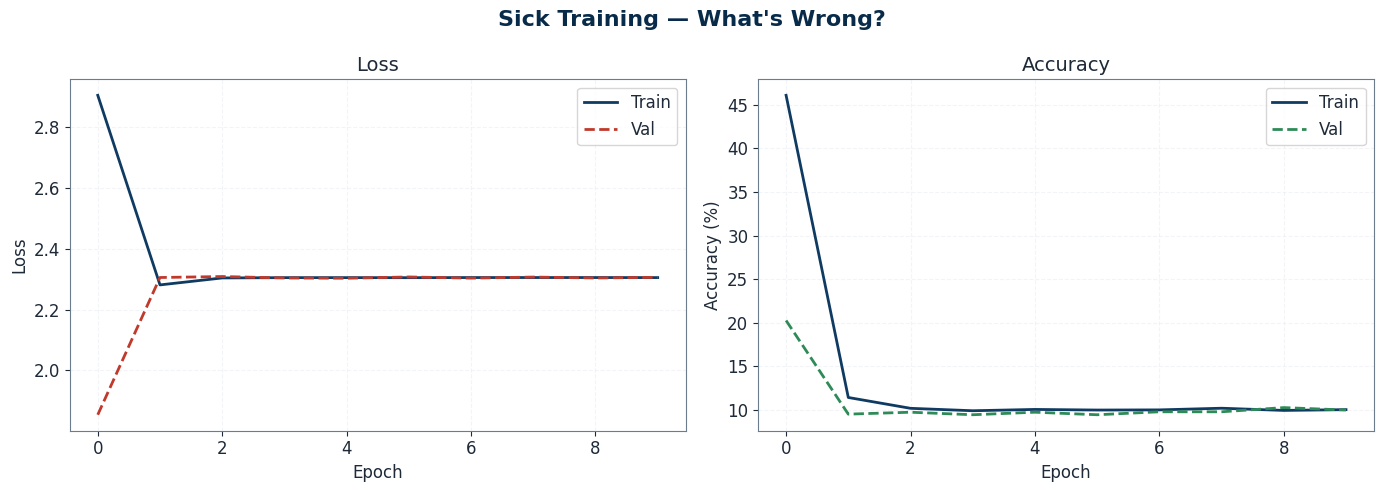

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# RUN THE SICK TRAINING — observe the output carefully
# ═══════════════════════════════════════════════════════════════════

transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])

full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(full_train, [50000, 10000],
                                                    generator=torch.Generator().manual_seed(42))
train_loader_ex3 = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader_ex3 = DataLoader(val_set, batch_size=256, shuffle=False)

print("🏥 Running the sick training... observe the symptoms.\n")
sick_model = SickNet().to(device)
sick_history = train_sick(sick_model, train_loader_ex3, val_loader_ex3, epochs=10, lr=0.05)
plot_curves(sick_history, title="Sick Training — What's Wrong?")


### Part A — Diagnosis *(written)*

Look at the loss/accuracy curves above and the code. Identify the **3 design problems** that are degrading performance.

For **each** problem, state:
- **What** the problem is
- **Where** in the code it comes from
- **What symptom** in the curves (or in the training printout) points to this specific problem
- **What the fix is** and **why** it helps


####  Your diagnosis (Part A)
le probleme c'est que Relu accepte juste les valeurs positives , donc si un valeur est negatif , ReLu rend la en 0

**Problem 1:**
- *What:* la methode de XAVIER ,le probleme c'est que Relu accepte juste les valeurs positives , donc si un valeur est negatif , ReLu rend la en 0
- *Where:* En initialisation
- *Symptom in curves:* Le réseau n'arrive pas à décoller dès le départ. La perte stagne à $2.30$ et l'Accuracy à $10\%$, car les signaux n'arrivent pas jusqu'au bout du réseau profond, empêchant les gradients de se calculer correctement.
- *Fix & why:* l'usage d'autre fonction comme KAIMING 'he' , elle donne des poids (weights) un peu plus grands , qui donne l'energie au signal pour traverse toutes le couches

**Problem 2:**
- *What:* learning rate tres grande pour pour adam , donc les neurones tombent en negatif, et a cause de Relu il se disparait
- *Where:* lr=0.05 en train_sick
- *Symptom in curves:* La chute instantanée et brutale (dès l'époque 1) sur le graphe. L'Accuracy s'écrase en une ligne parfaitement droite à $10\%$ (choix aléatoire pur) et la Loss devient une ligne plate à $\approx 2.30$. C'est le signe d'un modèle "mort" dès le premier pas d'optimisation.
- *Fix & why:* Le baisser a 0.001 , Elle permet au modèle d'apprendre de ses erreurs doucement et sûrement, sans crasher ses neurones.

**Problem 3:**
- *What:* l'enchainement des chouches
- *Where:* dans la fonction def forward
- *Symptom in curves:* Sans les deux bugs précédents, cela se traduirait par des courbes en dents de scie ou un plafonnement prématuré de l'Accuracy. Ici, combiné au LR de 0.05, cela amplifie le chaos mathématique et accélère l'effondrement plat visible sur les courbes.
- *Fix & why:* l'ajoue des batch entre chaque couche lineaire pour le nettoyage , recentrage des nombres apres chaque couches pour stabiliser l'apprentissage.



### Part B — Treatment *(code)*

Write the fixed version below. Apply all 3 fixes, retrain for 10 epochs, and plot the new curves **side by side** with the sick curves to demonstrate the improvement.

**Target:** Your fixed model should reach **> 87% validation accuracy** within 10 epochs.


🌟 Running the healthy training... observe the improvement.

Epoch  1/10 | Train Loss: 0.5151  Acc: 83.4% | Val Loss: 0.3564  Acc: 87.3%
Epoch  2/10 | Train Loss: 0.3399  Acc: 87.7% | Val Loss: 0.3275  Acc: 87.8%
Epoch  3/10 | Train Loss: 0.2998  Acc: 89.0% | Val Loss: 0.3231  Acc: 88.2%
Epoch  4/10 | Train Loss: 0.2729  Acc: 89.9% | Val Loss: 0.3176  Acc: 88.1%
Epoch  5/10 | Train Loss: 0.2543  Acc: 90.5% | Val Loss: 0.3081  Acc: 88.9%
Epoch  6/10 | Train Loss: 0.2337  Acc: 91.3% | Val Loss: 0.3162  Acc: 88.5%
Epoch  7/10 | Train Loss: 0.2187  Acc: 91.9% | Val Loss: 0.2984  Acc: 89.3%
Epoch  8/10 | Train Loss: 0.2040  Acc: 92.4% | Val Loss: 0.3120  Acc: 88.6%
Epoch  9/10 | Train Loss: 0.1895  Acc: 92.8% | Val Loss: 0.3143  Acc: 89.1%
Epoch 10/10 | Train Loss: 0.1750  Acc: 93.4% | Val Loss: 0.2978  Acc: 89.3%


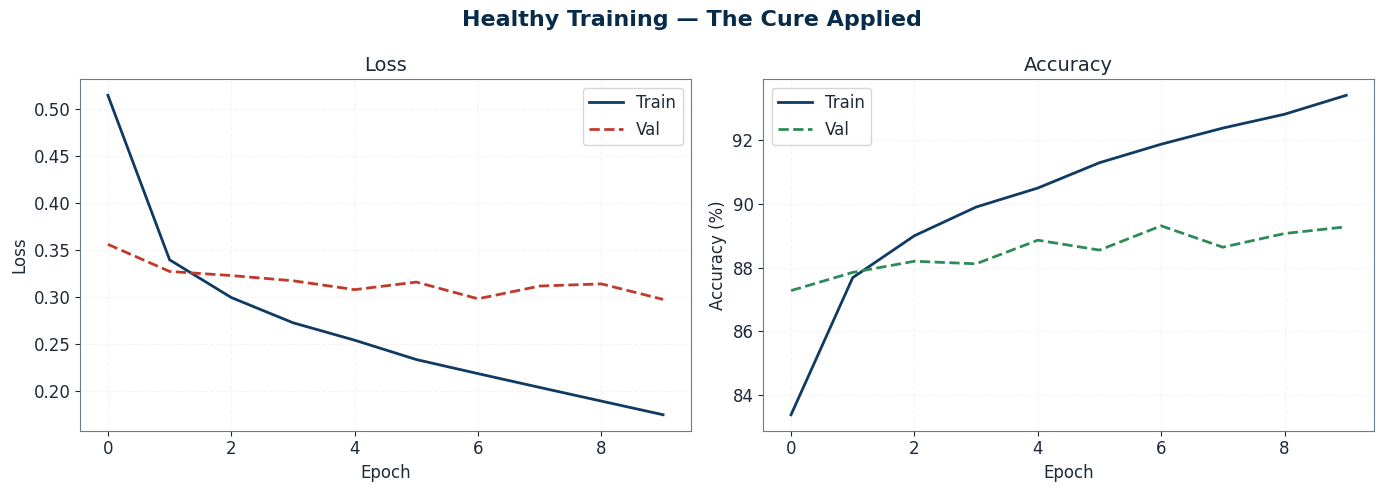

In [ ]:
#  YOUR CODE — Exercise 3, Part B
# Define the fixed model, train it, and compare curves.

# ═══════════════════════════════════════════════════════════════════
# THE HEALTHY TRAINING — APPLYING THE 3 CURES
# ═══════════════════════════════════════════════════════════════════

class HealthyNet(nn.Module):
    """A 6-layer MLP with BatchNorm and proper Kaiming initialization."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        # FIX 3: Added BatchNorm1d to stabilize the deep architecture
        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)

        self.fc5 = nn.Linear(64, 32)
        self.bn5 = nn.BatchNorm1d(32)

        self.fc6 = nn.Linear(32, 10)

        # FIX 1: Proper initialization for ReLU (Kaiming/He instead of Xavier)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.bn4(self.fc4(x)))
        x = F.relu(self.bn5(self.fc5(x)))
        x = self.fc6(x)
        return x


def plot_comparison(sick_hist, healthy_hist, title="Sick vs Healthy Training"):
    """Plot sick and healthy curves side-by-side to prove the fix works."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Loss Plot ---
    ax1.plot(sick_hist["val_loss"], color="red", linestyle=":", alpha=0.6, linewidth=2, label="Sick Val Loss")
    ax1.plot(healthy_hist["train_loss"], color="navy", linewidth=2, label="Healthy Train Loss")
    ax1.plot(healthy_hist["val_loss"], color="green", linestyle="--", linewidth=2, label="Healthy Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss Comparison")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Accuracy Plot ---
    ax2.plot(sick_hist["val_acc"], color="red", linestyle=":", alpha=0.6, linewidth=2, label="Sick Val Acc")
    ax2.plot(healthy_hist["train_acc"], color="navy", linewidth=2, label="Healthy Train Acc")
    ax2.plot(healthy_hist["val_acc"], color="green", linestyle="--", linewidth=2, label="Healthy Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy Comparison")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════════════
# RUN THE HEALTHY TRAINING — observe the improvement
# ═══════════════════════════════════════════════════════════════════

transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.2860,), (0.3530,))])

full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(full_train, [50000, 10000],
                                                    generator=torch.Generator().manual_seed(42))
train_loader_ex3 = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader_ex3 = DataLoader(val_set, batch_size=256, shuffle=False)

print("🌟 Running the healthy training... observe the improvement.\n")
healthy_model = HealthyNet().to(device)

# L'appel à l'entraînement avec la correction numéro 2 : lr=0.001 au lieu de 0.05
healthy_history = train_sick(healthy_model, train_loader_ex3, val_loader_ex3, epochs=10, lr=0.001)

# Affichage des nouvelles courbes
plot_curves(healthy_history, title="Healthy Training — The Cure Applied")


---

<div style="background:#F4F6F8; border-left:4px solid #CDD516; padding:16px 20px; border-radius:4px; margin:12px 0;">

**Before the session:** Make sure this notebook runs end-to-end (especially the data download and the sick training in Exercise 3). Have your written answers drafted. Come ready to explain.

**During the session:** Finalize your code, run everything, and wait for the professor to come to your station. When called, be ready to walk through your reasoning for any exercise.

</div>

<div style="text-align:center; color:#6B7D8D; font-size:12px; margin-top:20px; font-family:Calibri,sans-serif;">
Deep Learning — AI &amp; Big Data Engineering — UIR | 2025–2026
</div>
